# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Solución al problema de los N-cuerpos: método de Euler

In [1]:
%pip install -Uq pymcel rebound pandas plotly nbformat 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pymcel as pc
import numpy as np

/home/usuario/miniconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


Obtiene la posición del Sol para el día de hoy:

In [3]:
tabla, jd, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)
X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [4]:
# Obtener la posición de Júpiter usando el mismo patrón que para el Sol
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='Jupiter Barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)

X_jup

array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09, -1.21253772e+04,
       -4.61863891e+03,  2.90510926e+02])

Extraigamos posiciones y velocidades directamente del vector de estado:

In [5]:
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

r_jup_0 = X_jup[:3]
v_jup_0 = X_jup[3:]

Apliquemos el método de Euler:

In [6]:
deltat = 1 * 86400 # un día en segundos
r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_0, r_jup_dt

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]))

In [7]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [8]:
# Calculamos la velocidad del Sol en t + deltat usando la misma aproximación
# (aceleración debida a la gravedad de Júpiter)

rij_vec_sol = r_sol_0 - r_jup_0          # vector desde Júpiter hasta el Sol
v_sol_dt = v_sol_0 - mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat

v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

Calculemos las posiciones en días sucesivos por 12 años y grafiquemos:

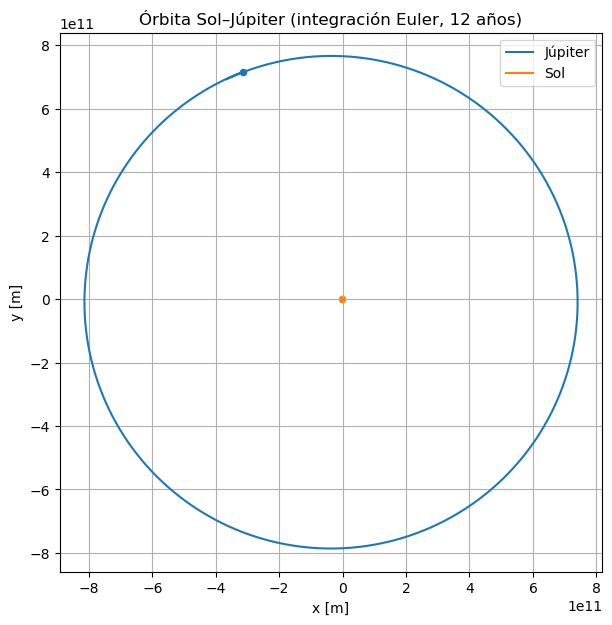

In [40]:
import matplotlib.pyplot as plt

# Tiempo total: 12 años en segundos (aprox.)
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

# Paso de integración: ya tenemos deltat = 1 día en segundos
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist = []
r_sol_hist = []

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # Vector de separación Júpiter - Sol
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)

    # Aceleraciones mutuas (dos cuerpos)
    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jup * rij / r**3  # misma dirección, signo contrario y masa diferente

    # Integración tipo Euler 
    v_jup = v_jup + a_jup * deltat
    r_jup = r_jup + v_jup * deltat

    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Euler, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

Veamos cómo evoluciona la energía total del sistema:

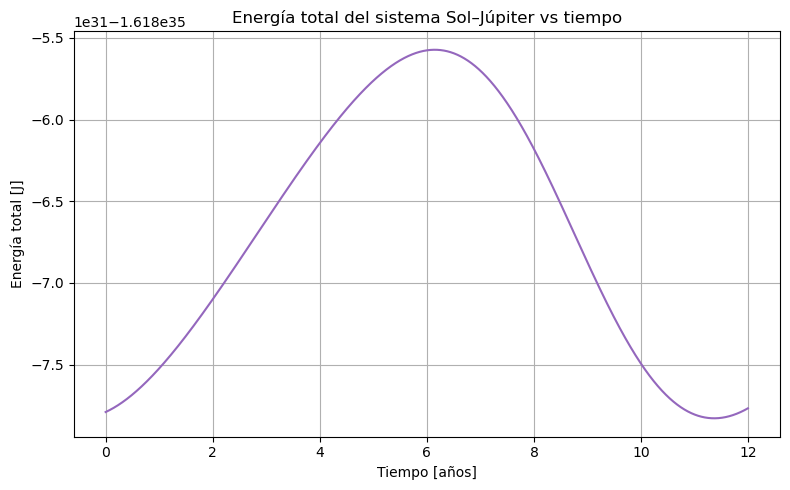

In [10]:
# Cálculo y gráfico de la energía total (cinética + potencial) en función del tiempo

# Masas a partir de parámetros gravitacionales (mu = G*M)
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_sol = mu_sol / G
M_jup = mu_jup / G

# Tiempo asociado a cada paso (en segundos y en años)
t_array = np.arange(N_steps) * deltat          # s
t_years = t_array / seconds_per_year          # años

# Posición relativa Júpiter–Sol en cada instante
r_rel = r_jup_hist - r_sol_hist               # vector r_jup - r_sol
r_norm = np.linalg.norm(r_rel, axis=1)        # distancia |r|

# Energía potencial gravitatoria (dos cuerpos)
U = -G * M_sol * M_jup / r_norm               # J

# Velocidades relativas aproximadas por diferencias finitas hacia adelante
v_jup_hist = np.diff(r_jup_hist, axis=0) / deltat
v_sol_hist = np.diff(r_sol_hist, axis=0) / deltat

# Igualamos longitud de arrays de energía recortando el último paso en U
U = U[:-1]
t_years_energy = t_years[:-1]

# Energías cinéticas
K_jup = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

E_total = K_jup + K_sol + U    # energía total

plt.figure(figsize=(8, 5))
plt.plot(t_years_energy, E_total, color="tab:purple")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía total [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
E_total[0], E_total[-1]  # energía total en el primer paso   

(np.float64(-1.6187790351156131e+35), np.float64(-1.6187767638635438e+35))

## integradores simplécticos (?)
Leap-frog permite corregir el error de acumulación de energía fantasma a lo largo de intervalos extensos de tiempo. Resolvamos lo que anteriormente se hizo con Euler, por este nuevo método:



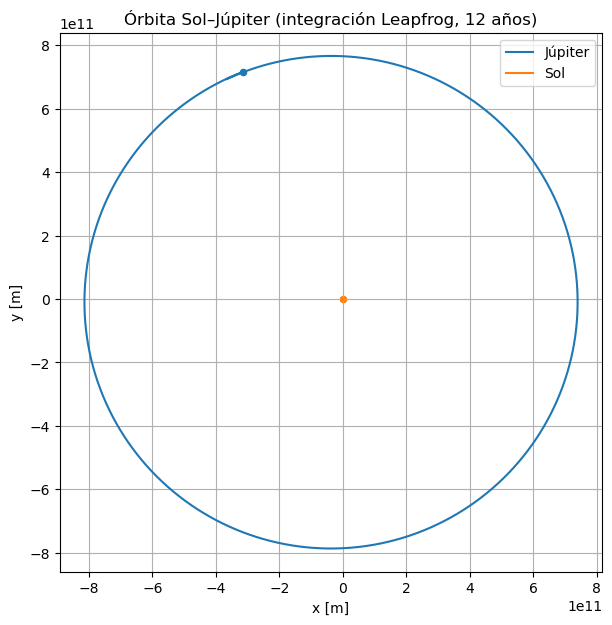

In [34]:
# Tiempo total: 12 años en segundos (aprox.)
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

# Paso de integración: ya tenemos deltat = 1 día en segundos
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist, r_sol_hist = [], []

# Calculamos la aceleración inicial
rij = r_jup - r_sol
r = np.linalg.norm(rij)
a_jup = -mu_sol * rij / r**3
a_sol = mu_jup * rij / r**3

# Leapfrog: primer medio paso para las velocidades
v_jup = v_jup + 0.5 * a_jup * deltat
v_sol = v_sol + 0.5 * a_sol * deltat

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # Actualizamos posiciones (paso completo)
    r_jup = r_jup + v_jup * deltat
    r_sol = r_sol + v_sol * deltat

    # Calculamos la nueva aceleración
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)
    a_jup = -mu_sol * rij / r**3
    a_sol = mu_jup * rij / r**3

    # Actualizamos velocidades (paso completo)
    v_jup = v_jup + a_jup * deltat
    v_sol = v_sol + a_sol * deltat

# Leapfrog: último medio paso para las velocidades
v_jup = v_jup + 0.5 * a_jup * deltat
v_sol = v_sol + 0.5 * a_sol * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Leapfrog, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

In [35]:
# Energía cinética de Júpiter y el Sol
K_jup_leapfrog = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol_leapfrog = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

# Energía potencial gravitatoria
U_leapfrog = -G * M_sol * M_jup / r_norm[:-1]  # r_norm ya tiene un paso más

# Energía total
E_total_leapfrog = K_jup_leapfrog + K_sol_leapfrog + U_leapfrog

# Imprimimos la energía total en el primer y último paso
print(f"Energía total inicial (Leapfrog): {E_total_leapfrog[0]:.3e} J")
print(f"Energía total final (Leapfrog): {E_total_leapfrog[-1]:.3e} J")

Energía total inicial (Leapfrog): -1.619e+35 J
Energía total final (Leapfrog): -1.619e+35 J


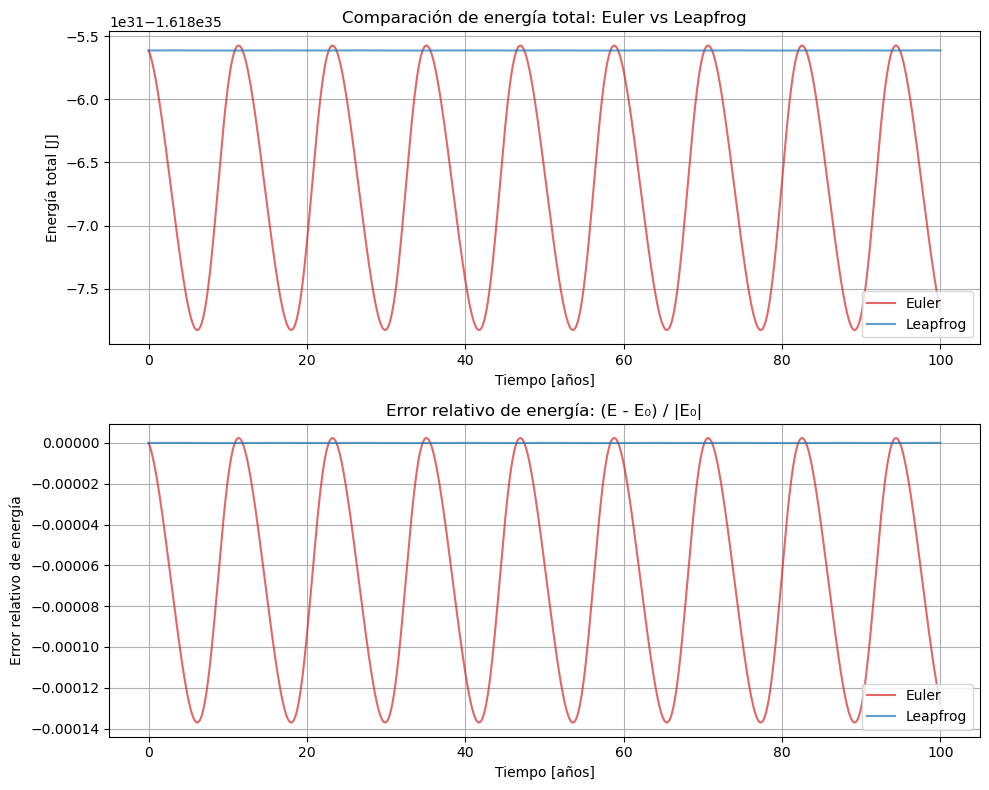

Energía inicial Euler: -1.618561e+35 J
Energía final Euler: -1.618767e+35 J
Cambio relativo Euler: -0.0127%

Energía inicial Leapfrog: -1.618561e+35 J
Energía final Leapfrog: -1.618561e+35 J
Cambio relativo Leapfrog: 0.000001%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# MÉTODO DE EULER
# ============================================================
years = 100
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades
r_jup_euler = r_jup_0.copy()
v_jup_euler = v_jup_0.copy()
r_sol_euler = r_sol_0.copy()
v_sol_euler = v_sol_0.copy()

# Listas para guardar la energía total
E_euler = []

# Masas (asumiendo que están definidas)
# M_sol y M_jup deben estar definidas previamente
G = 6.67430e-11  # Constante gravitacional en m^3 kg^-1 s^-2

for _ in range(N_steps):
    # Energía cinética
    Ec_jup = 0.5 * M_jup * np.linalg.norm(v_jup_euler)**2
    Ec_sol = 0.5 * M_sol * np.linalg.norm(v_sol_euler)**2
    Ec = Ec_jup + Ec_sol

    # Energía potencial gravitacional
    rij = r_jup_euler - r_sol_euler
    r = np.linalg.norm(rij)
    Ep = -G * M_sol * M_jup / r

    # Energía total
    E_euler.append(Ec + Ep)

    # Integración Euler
    a_jup = -mu_sol * rij / r**3
    a_sol = mu_jup * rij / r**3

    v_jup_euler = v_jup_euler + a_jup * deltat
    r_jup_euler = r_jup_euler + v_jup_euler * deltat

    v_sol_euler = v_sol_euler + a_sol * deltat
    r_sol_euler = r_sol_euler + v_sol_euler * deltat

E_euler = np.array(E_euler)

# ============================================================
# MÉTODO DE LEAPFROG
# ============================================================
r_jup_lf = r_jup_0.copy()
v_jup_lf = v_jup_0.copy()
r_sol_lf = r_sol_0.copy()
v_sol_lf = v_sol_0.copy()

E_leapfrog = []

# Aceleración inicial
rij = r_jup_lf - r_sol_lf
r = np.linalg.norm(rij)
a_jup = -mu_sol * rij / r**3
a_sol = mu_jup * rij / r**3

# Medio paso inicial para velocidades
v_jup_lf = v_jup_lf + 0.5 * a_jup * deltat
v_sol_lf = v_sol_lf + 0.5 * a_sol * deltat

for _ in range(N_steps):
    # Energía cinética (usamos velocidades sincronizadas)
    # Para calcular energía correctamente en Leapfrog, necesitamos
    # velocidades en el mismo tiempo que las posiciones
    v_jup_sync = v_jup_lf - 0.5 * a_jup * deltat
    v_sol_sync = v_sol_lf - 0.5 * a_sol * deltat

    Ec_jup = 0.5 * M_jup * np.linalg.norm(v_jup_sync)**2
    Ec_sol = 0.5 * M_sol * np.linalg.norm(v_sol_sync)**2
    Ec = Ec_jup + Ec_sol    import matplotlib.pyplot as plt
    import numpy as np
    
    # ============================================================
    # MÉTODO DE EULER (con historial de posiciones)
    # ============================================================
    years = 100
    seconds_per_year = 365.25 * 86400
    T_total = years * seconds_per_year
    N_steps = int(T_total // deltat)
    
    # Inicializamos posiciones y velocidades
    r_jup_euler = r_jup_0.copy()
    v_jup_euler = v_jup_0.copy()
    r_sol_euler = r_sol_0.copy()
    v_sol_euler = v_sol_0.copy()
    
    # Listas para guardar trayectoria y energía
    r_jup_hist_euler = []
    r_sol_hist_euler = []
    E_euler = []
    
    G = 6.67430e-11
    
    for _ in range(N_steps):
        r_jup_hist_euler.append(r_jup_euler.copy())
        r_sol_hist_euler.append(r_sol_euler.copy())
    
        # Energía
        Ec = 0.5 * M_jup * np.linalg.norm(v_jup_euler)**2 + 0.5 * M_sol * np.linalg.norm(v_sol_euler)**2
        rij = r_jup_euler - r_sol_euler
        r = np.linalg.norm(rij)
        Ep = -G * M_sol * M_jup / r
        E_euler.append(Ec + Ep)
    
        # Integración Euler
        a_jup = -mu_sol * rij / r**3
        a_sol = mu_jup * rij / r**3
    
        v_jup_euler = v_jup_euler + a_jup * deltat
        r_jup_euler = r_jup_euler + v_jup_euler * deltat
        v_sol_euler = v_sol_euler + a_sol * deltat
        r_sol_euler = r_sol_euler + v_sol_euler * deltat
    
    r_jup_hist_euler = np.array(r_jup_hist_euler)
    r_sol_hist_euler = np.array(r_sol_hist_euler)
    E_euler = np.array(E_euler)
    
    # ============================================================
    # MÉTODO DE LEAPFROG (con historial de posiciones)
    # ============================================================
    r_jup_lf = r_jup_0.copy()
    v_jup_lf = v_jup_0.copy()
    r_sol_lf = r_sol_0.copy()
    v_sol_lf = v_sol_0.copy()
    
    r_jup_hist_lf = []
    r_sol_hist_lf = []
    E_leapfrog = []
    
    # Aceleración inicial
    rij = r_jup_lf - r_sol_lf
    r = np.linalg.norm(rij)
    a_jup = -mu_sol * rij / r**3
    a_sol = mu_jup * rij / r**3
    
    # Medio paso inicial
    v_jup_lf = v_jup_lf + 0.5 * a_jup * deltat
    v_sol_lf = v_sol_lf + 0.5 * a_sol * deltat
    
    for _ in range(N_steps):
        r_jup_hist_lf.append(r_jup_lf.copy())
        r_sol_hist_lf.append(r_sol_lf.copy())
    
        # Energía (velocidades sincronizadas)
        v_jup_sync = v_jup_lf - 0.5 * a_jup * deltat
        v_sol_sync = v_sol_lf - 0.5 * a_sol * deltat
        Ec = 0.5 * M_jup * np.linalg.norm(v_jup_sync)**2 + 0.5 * M_sol * np.linalg.norm(v_sol_sync)**2
        rij = r_jup_lf - r_sol_lf
        r = np.linalg.norm(rij)
        Ep = -G * M_sol * M_jup / r
        E_leapfrog.append(Ec + Ep)
    
        # Posiciones
        r_jup_lf = r_jup_lf + v_jup_lf * deltat
        r_sol_lf = r_sol_lf + v_sol_lf * deltat
    
        # Nueva aceleración
        rij = r_jup_lf - r_sol_lf
        r = np.linalg.norm(rij)
        a_jup = -mu_sol * rij / r**3
        a_sol = mu_jup * rij / r**3
    
        # Velocidades
        v_jup_lf = v_jup_lf + a_jup * deltat
        v_sol_lf = v_sol_lf + a_sol * deltat
    
    r_jup_hist_lf = np.array(r_jup_hist_lf)
    r_sol_hist_lf = np.array(r_sol_hist_lf)
    E_leapfrog = np.array(E_leapfrog)    import matplotlib.pyplot as plt
    import numpy as np
    
    # ============================================================
    # MÉTODO DE EULER (con historial de posiciones)
    # ============================================================
    years = 100
    seconds_per_year = 365.25 * 86400
    T_total = years * seconds_per_year
    N_steps = int(T_total // deltat)
    
    # Inicializamos posiciones y velocidades
    r_jup_euler = r_jup_0.copy()
    v_jup_euler = v_jup_0.copy()
    r_sol_euler = r_sol_0.copy()
    v_sol_euler = v_sol_0.copy()
    
    # Listas para guardar trayectoria y energía
    r_jup_hist_euler = []
    r_sol_hist_euler = []
    E_euler = []
    
    G = 6.67430e-11
    
    for _ in range(N_steps):
        r_jup_hist_euler.append(r_jup_euler.copy())
        r_sol_hist_euler.append(r_sol_euler.copy())
    
        # Energía
        Ec = 0.5 * M_jup * np.linalg.norm(v_jup_euler)**2 + 0.5 * M_sol * np.linalg.norm(v_sol_euler)**2
        rij = r_jup_euler - r_sol_euler
        r = np.linalg.norm(rij)
        Ep = -G * M_sol * M_jup / r
        E_euler.append(Ec + Ep)
    
        # Integración Euler
        a_jup = -mu_sol * rij / r**3
        a_sol = mu_jup * rij / r**3
    
        v_jup_euler = v_jup_euler + a_jup * deltat
        r_jup_euler = r_jup_euler + v_jup_euler * deltat
        v_sol_euler = v_sol_euler + a_sol * deltat
        r_sol_euler = r_sol_euler + v_sol_euler * deltat
    
    r_jup_hist_euler = np.array(r_jup_hist_euler)
    r_sol_hist_euler = np.array(r_sol_hist_euler)
    E_euler = np.array(E_euler)
    
    # ============================================================
    # MÉTODO DE LEAPFROG (con historial de posiciones)
    # ============================================================
    r_jup_lf = r_jup_0.copy()
    v_jup_lf = v_jup_0.copy()
    r_sol_lf = r_sol_0.copy()
    v_sol_lf = v_sol_0.copy()
    
    r_jup_hist_lf = []
    r_sol_hist_lf = []
    E_leapfrog = []
    
    # Aceleración inicial
    rij = r_jup_lf - r_sol_lf
    r = np.linalg.norm(rij)
    a_jup = -mu_sol * rij / r**3
    a_sol = mu_jup * rij / r**3
    
    # Medio paso inicial
    v_jup_lf = v_jup_lf + 0.5 * a_jup * deltat
    v_sol_lf = v_sol_lf + 0.5 * a_sol * deltat
    
    for _ in range(N_steps):
        r_jup_hist_lf.append(r_jup_lf.copy())
        r_sol_hist_lf.append(r_sol_lf.copy())
    
        # Energía (velocidades sincronizadas)
        v_jup_sync = v_jup_lf - 0.5 * a_jup * deltat
        v_sol_sync = v_sol_lf - 0.5 * a_sol * deltat
        Ec = 0.5 * M_jup * np.linalg.norm(v_jup_sync)**2 + 0.5 * M_sol * np.linalg.norm(v_sol_sync)**2
        rij = r_jup_lf - r_sol_lf
        r = np.linalg.norm(rij)
        Ep = -G * M_sol * M_jup / r
        E_leapfrog.append(Ec + Ep)
    
        # Posiciones
        r_jup_lf = r_jup_lf + v_jup_lf * deltat
        r_sol_lf = r_sol_lf + v_sol_lf * deltat
    
        # Nueva aceleración
        rij = r_jup_lf - r_sol_lf
        r = np.linalg.norm(rij)
        a_jup = -mu_sol * rij / r**3
        a_sol = mu_jup * rij / r**3
    
        # Velocidades
        v_jup_lf = v_jup_lf + a_jup * deltat
        v_sol_lf = v_sol_lf + a_sol * deltat
    
    r_jup_hist_lf = np.array(r_jup_hist_lf)
    r_sol_hist_lf = np.array(r_sol_hist_lf)
    E_leapfrog = np.array(E_leapfrog)

    # Energía potencial gravitacional
    rij = r_jup_lf - r_sol_lf
    r = np.linalg.norm(rij)
    Ep = -G * M_sol * M_jup / r

    # Energía total
    E_leapfrog.append(Ec + Ep)

    # Actualizamos posiciones (paso completo)
    r_jup_lf = r_jup_lf + v_jup_lf * deltat
    r_sol_lf = r_sol_lf + v_sol_lf * deltat

    # Nueva aceleración
    rij = r_jup_lf - r_sol_lf
    r = np.linalg.norm(rij)
    a_jup = -mu_sol * rij / r**3
    a_sol = mu_jup * rij / r**3

    # Actualizamos velocidades (paso completo)
    v_jup_lf = v_jup_lf + a_jup * deltat
    v_sol_lf = v_sol_lf + a_sol * deltat

E_leapfrog = np.array(E_leapfrog)

# ============================================================
# GRÁFICA COMPARATIVA DE ENERGÍA
# ============================================================
tiempo = np.arange(N_steps) * deltat / seconds_per_year  # en años

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Energía total
axes[0].plot(tiempo, E_euler, label="Euler", color="tab:red", alpha=0.7)
axes[0].plot(tiempo, E_leapfrog, label="Leapfrog", color="tab:blue", alpha=0.7)
axes[0].set_xlabel("Tiempo [años]")
axes[0].set_ylabel("Energía total [J]")
axes[0].set_title("Comparación de energía total: Euler vs Leapfrog")
axes[0].legend()
axes[0].grid(True)

# Error relativo de energía
E0_euler = E_euler[0]
E0_leapfrog = E_leapfrog[0]

error_euler = (E_euler - E0_euler) / np.abs(E0_euler)
error_leapfrog = (E_leapfrog - E0_leapfrog) / np.abs(E0_leapfrog)

axes[1].plot(tiempo, error_euler, label="Euler", color="tab:red", alpha=0.7)
axes[1].plot(tiempo, error_leapfrog, label="Leapfrog", color="tab:blue", alpha=0.7)
axes[1].set_xlabel("Tiempo [años]")
axes[1].set_ylabel("Error relativo de energía")
axes[1].set_title("Error relativo de energía: (E - E₀) / |E₀|")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Imprimir estadísticas
print(f"Energía inicial Euler: {E0_euler:.6e} J")
print(f"Energía final Euler: {E_euler[-1]:.6e} J")
print(f"Cambio relativo Euler: {error_euler[-1]*100:.4f}%\n")

print(f"Energía inicial Leapfrog: {E0_leapfrog:.6e} J")
print(f"Energía final Leapfrog: {E_leapfrog[-1]:.6e} J")
print(f"Cambio relativo Leapfrog: {error_leapfrog[-1]*100:.6f}%")

Euler: La energía total aumentará o disminuirá sistemáticamente con el tiempo (no conserva energía).


Leapfrog: La energía total oscilará alrededor del valor inicial pero se mantendrá acotada (método simpléctico, conserva energía a largo plazo).


## Numba
Útil para compilar grandes extensiones, en lugar de línea a línea
con @njit

In [39]:
from numba import njit

ModuleNotFoundError: No module named 'numba'